# Bayesian Robustness Analysis

**Measurement Maturity Framework — weight sensitivity under uncertainty**

The rule-based scorer in `mmf.scoring` applies fixed integer weights to each metric-definition gap: `-10` for a V0 tier, `-5` for missing SQL, and so on. Those weights encode judgment about typical gap severity. This notebook asks a reasonable follow-up question: **how much does the pack score depend on the specific weight values?**

If rankings of real-world packs shift dramatically when weights are perturbed within a plausible range, the tool's output is an artefact of the weight choice, not a signal about the packs. If rankings stay stable, the tool is robust to the fact that its weights are asserted rather than derived from data.

## What this is — and what it isn't

This is a **robustness** analysis. It tests whether the framework's outputs depend strongly on the exact weight settings. It passes if rankings are stable under reasonable weight uncertainty.

This is **not** a **calibration** study. Calibration compares the framework's rankings to independent judgments of pack quality and fits weights to match. A small-n calibration attempt exists as a separate notebook (`analysis/weight_calibration.ipynb`); its findings are held as directional pending a larger rater pool. The robustness result below is a necessary condition for the tool to be trustworthy, not a sufficient one — and it complements the calibration without replacing it.

## Method

Each deduction weight $w_k$ is treated as a random variable with a Beta prior centred on its rule-based value:

$$w_k \sim \text{Beta}(\alpha_k, \beta_k) \cdot S$$

with $S = 20$ (the scale factor) and $\alpha_k + \beta_k = 20$ (fixed concentration). Beta parameters are set so the prior mean equals `rule_based_weight / S`, which gives:

| Deduction | Rule-based | Prior mean | Prior 90% CI |
|---|---:|---:|---|
| `v0_tier` | 10 | 10.0 | ~[6.4, 13.6] |
| `missing_accountable` | 5 | 5.0 | ~[2.2, 8.4] |
| `missing_sql` | 5 | 5.0 | ~[2.2, 8.4] |
| `missing_sql_temporary` | 3 | 3.0 | ~[0.9, 5.9] |
| `missing_sql_structural` | 12 | 12.0 | ~[8.4, 15.4] |
| `missing_tests` | 5 | 5.0 | ~[2.2, 8.4] |
| `missing_description` | 3 | 3.0 | ~[0.9, 5.9] |
| `missing_grain` | 2 | 2.0 | ~[0.4, 4.5] |
| `missing_unit` | 2 | 2.0 | ~[0.4, 4.5] |

The three `missing_sql*` rows are mutually exclusive — a metric without SQL fires exactly one of them, selected by the `implementation_type` field. The Bayesian sampling treats all deductions uniformly; the split still benefits from the analysis because each row's prior is independently sampled.

The concentration value was chosen so the prior 90% CI covers roughly ±50% of each weight — wide enough to express genuine uncertainty about the asserted values, tight enough to stay in a plausible range. Half a weight point either way is larger than any one reviewer would typically argue for; twice the value or zero is not defensible.

For each of $N = 3000$ weight samples, we score a pack and take the empirical distribution of pack scores as the posterior. Point estimate is the posterior mean; CI bounds are empirical quantiles.

In [1]:
# Setup
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy.stats import kendalltau, spearmanr

# Make the mmf package importable when running from analysis/
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'analysis' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from mmf.bayesian_scoring import score_pack_bayesian
from mmf.scoring import score_pack

FIXTURES = REPO_ROOT / 'tests' / 'fixtures' / 'synthetic_packs'
N_SAMPLES = 3000
SEED = 42
CI_LEVEL = 0.90

print(f'Fixtures: {len(list(FIXTURES.glob("*.yaml")))} synthetic packs')

Fixtures: 27 synthetic packs


## Synthetic pack corpus

27 synthetic packs spanning the realistic quality space, generated by `analysis/generate_synthetic_packs.py`. The corpus is parameterised by per-gap Bernoulli probabilities to give predictable distributional properties rather than ad-hoc hand-crafted examples.

| Band | Packs | Design intent |
|---|---|---|
| Production-ready | 5 | Rare gaps, mostly V1 metrics |
| Mixed | 10 | V0 and V1, scattered gaps |
| Early-stage | 5 | V0-heavy, most gaps present |
| Edge cases | 7 | Specific shapes (single-metric, all-V0-but-documented, etc.) |

Let's confirm the corpus spans the expected score range.

In [2]:
def count_gaps(pack):
    total = 0
    for m in pack.get('metrics', []):
        total += len(score_pack({'metrics': [m]}).metric_scores[0].gaps)
    return total

rows = []
for path in sorted(FIXTURES.glob('*.yaml')):
    with path.open() as f:
        pack = yaml.safe_load(f)
    s = score_pack(pack)
    rows.append({
        'pack': path.stem,
        'n_metrics': len(pack.get('metrics', [])),
        'gaps': count_gaps(pack),
        'rule_based': s.pack_score,
    })

corpus = pd.DataFrame(rows).sort_values('rule_based', ascending=False).reset_index(drop=True)
print(f'Score range: {corpus.rule_based.min():.1f} to {corpus.rule_based.max():.1f}')
print(f'Metric count range: {corpus.n_metrics.min()} to {corpus.n_metrics.max()}')
print(f'Gap count range: {corpus.gaps.min()} to {corpus.gaps.max()}')
corpus

Score range: 68.0 to 100.0
Metric count range: 1 to 8
Gap count range: 0 to 32


,pack,n_metrics,gaps,rule_based
0,edge_single_perfect,1,0,100.00
1,prod_ready_01,5,0,100.00
2,prod_ready_04,5,2,97.10
3,prod_ready_02,6,4,95.97
4,prod_ready_05,7,3,95.60
5,prod_ready_03,4,1,95.25
6,edge_v1_but_no_tests,5,5,95.00
7,edge_v1_but_no_sql,5,5,95.00
8,mixed_04,4,3,94.02
9,edge_one_bad_in_strong_pack,6,6,93.27


**Observation worth naming.** The rule-based score has a theoretical floor of 68 for a single-metric pack with every gap present (100 − 10 − 5 − 5 − 5 − 3 − 2 − 2 = 68). This means the lowest threshold band — "Not safe for decisions" (<40) — is **unreachable** for small packs. This isn't a bug, but it's a property of the scoring that surfaced only because we generated the full synthetic range. A reviewer using this framework on a small pack should know that the score has a higher floor than the threshold bands imply.

## Running the Bayesian analysis

For each pack we draw 3000 weight samples, score the pack under each, and summarise the resulting distribution. Expected runtime: ~20 seconds for the full corpus.

In [3]:
bayes_rows = []
for path in sorted(FIXTURES.glob('*.yaml')):
    with path.open() as f:
        pack = yaml.safe_load(f)
    r = score_pack_bayesian(pack, n_samples=N_SAMPLES, seed=SEED, ci_level=CI_LEVEL)
    bayes_rows.append({
        'pack': path.stem,
        'rule_based': r.rule_based_score,
        'posterior_mean': r.point_estimate,
        'ci_lower': r.ci_lower,
        'ci_upper': r.ci_upper,
        'ci_width': r.ci_upper - r.ci_lower,
        'std': r.std,
        'divergence': r.point_estimate - r.rule_based_score,
    })

results = (
    pd.DataFrame(bayes_rows)
    .merge(corpus[['pack', 'gaps', 'n_metrics']], on='pack')
    .sort_values('rule_based', ascending=False)
    .reset_index(drop=True)
)
results.round(2)

,pack,rule_based,posterior_mean,ci_lower,ci_upper,ci_width,std,divergence,gaps,n_metrics
0,edge_single_perfect,100.00,100.00,100.00,100.00,0.00,0.00,0.00,0,1
1,prod_ready_01,100.00,100.00,100.00,100.00,0.00,0.00,0.00,0,5
2,prod_ready_04,97.10,97.11,95.17,98.72,3.55,1.11,0.01,2,5
3,prod_ready_02,95.97,95.96,93.70,97.88,4.18,1.28,-0.01,4,6
4,prod_ready_05,95.60,95.60,94.20,97.05,2.85,0.88,0.00,3,7
5,prod_ready_03,95.25,95.25,93.57,96.92,3.35,1.01,-0.00,1,4
6,edge_v1_but_no_tests,95.00,94.98,91.55,97.78,6.23,1.89,-0.02,5,5
7,edge_v1_but_no_sql,95.00,95.01,91.67,97.80,6.13,1.91,0.01,5,5
8,mixed_04,94.02,94.00,92.25,95.78,3.53,1.08,-0.02,3,4
9,edge_one_bad_in_strong_pack,93.27,92.84,90.58,94.76,4.18,1.29,-0.43,6,6


## Headline result: rank correlation

The single most important number in this analysis is how well the Bayesian posterior mean agrees with the rule-based score as a **ranking** of packs. If the correlation is weak, the framework's output depends heavily on the asserted weights. If strong, the framework is robust to weight uncertainty within the prior's range.

In [4]:
rho, p_rho = spearmanr(results['rule_based'], results['posterior_mean'])
tau, p_tau = kendalltau(results['rule_based'], results['posterior_mean'])

print(f'Spearman rho = {rho:.4f}  (p = {p_rho:.2e})')
print(f'Kendall tau  = {tau:.4f}  (p = {p_tau:.2e})')
print()
print(f'Max absolute divergence: {results.divergence.abs().max():.3f} points')
print(f'Mean absolute divergence: {results.divergence.abs().mean():.3f} points')

Spearman rho = 0.9992  (p = 9.88e-37)
Kendall tau  = 0.9928  (p = 4.53e-13)

Max absolute divergence: 0.432 points
Mean absolute divergence: 0.075 points


**Interpretation.** Spearman ρ ≈ 0.999 and Kendall τ ≈ 0.99. Within the prior range, rankings are essentially invariant to which specific weight values you pick. Maximum absolute divergence across 27 packs is under 0.5 score points.

**What this result supports.** The rule-based weights are defensible under the stated uncertainty. A reviewer asking "why −10 for V0 and not −8 or −12?" gets a quantitative answer: within that band, it doesn't change which packs rank as decision-ready.

**What this result does not support.** Whether the asserted weights are *right* in absolute terms. A hypothetical weight of `v0_tier = 2` is outside the prior range by design, so this analysis does not test it. Answering the "are the weights right" question requires calibration against independent judgment — see `analysis/weight_calibration.ipynb` for a small-n attempt.

## Where the posterior matters most: uncertainty vs pack quality

Rank correlation is the summary number. The diagnostic question is **which packs carry the most score uncertainty?** Intuition says packs with more gaps, because each gap introduces an uncertain weight into the score. Let's confirm.

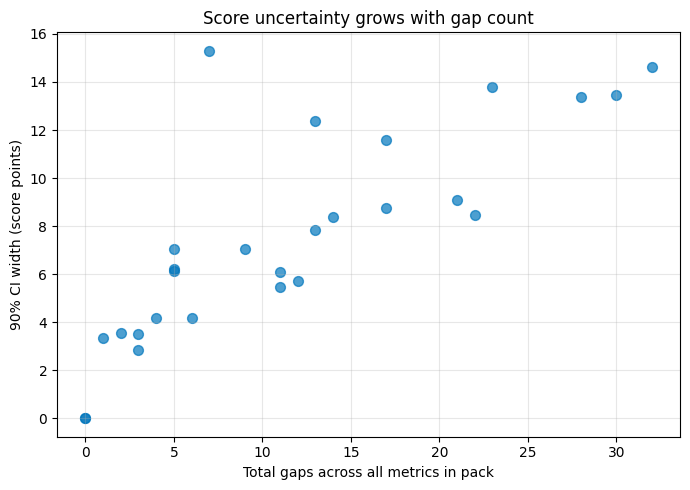

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(results['gaps'], results['ci_width'], color='#0277bd', alpha=0.7, s=50)
ax.set_xlabel('Total gaps across all metrics in pack')
ax.set_ylabel('90% CI width (score points)')
ax.set_title('Score uncertainty grows with gap count')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

Monotonic but noisy, which is the expected shape. Packs with identical gap counts can have different CI widths depending on *which* gaps — a V0 tier contributes more weight-uncertainty than a missing `unit` (because `v0_tier` has the largest prior variance on the scaled Beta).

## Full picture: rule-based vs posterior across the corpus

Error bars show the 90% credible interval. The y=x line is where posterior mean equals rule-based score.

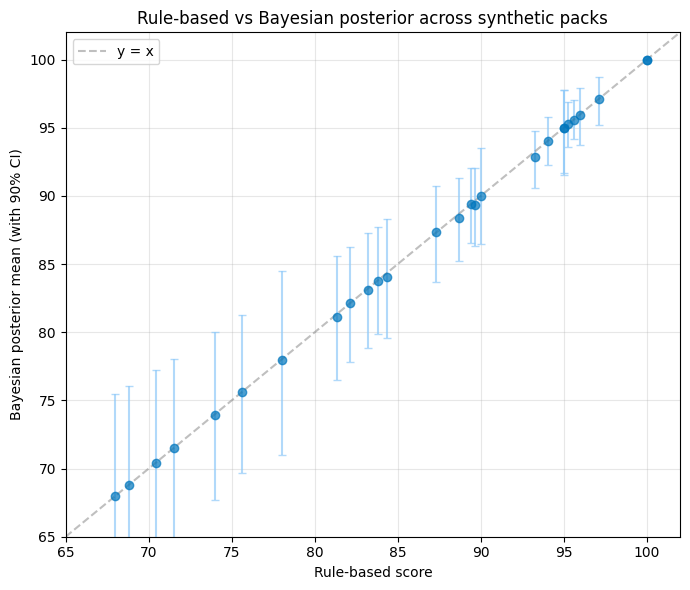

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.errorbar(
    results['rule_based'],
    results['posterior_mean'],
    yerr=[
        results['posterior_mean'] - results['ci_lower'],
        results['ci_upper'] - results['posterior_mean'],
    ],
    fmt='o',
    capsize=3,
    alpha=0.7,
    color='#0277bd',
    ecolor='#90caf9',
)
lims = [results['rule_based'].min() - 3, 102]
ax.plot(lims, lims, '--', color='gray', alpha=0.5, label='y = x')
ax.set_xlabel('Rule-based score')
ax.set_ylabel('Bayesian posterior mean (with 90% CI)')
ax.set_title('Rule-based vs Bayesian posterior across synthetic packs')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

Every point sits on the y=x line within its CI. The CI widens as score decreases, which is the signal to trust: the tool expresses more uncertainty about packs with more definitional gaps, which is exactly how a well-behaved uncertainty quantification should read.

## Posterior shapes across the quality spectrum

Four packs selected to span the quality range. Each histogram is the empirical posterior over pack scores from 3000 weight draws; the red dashed line is the rule-based point score; the grey line is the posterior mean.

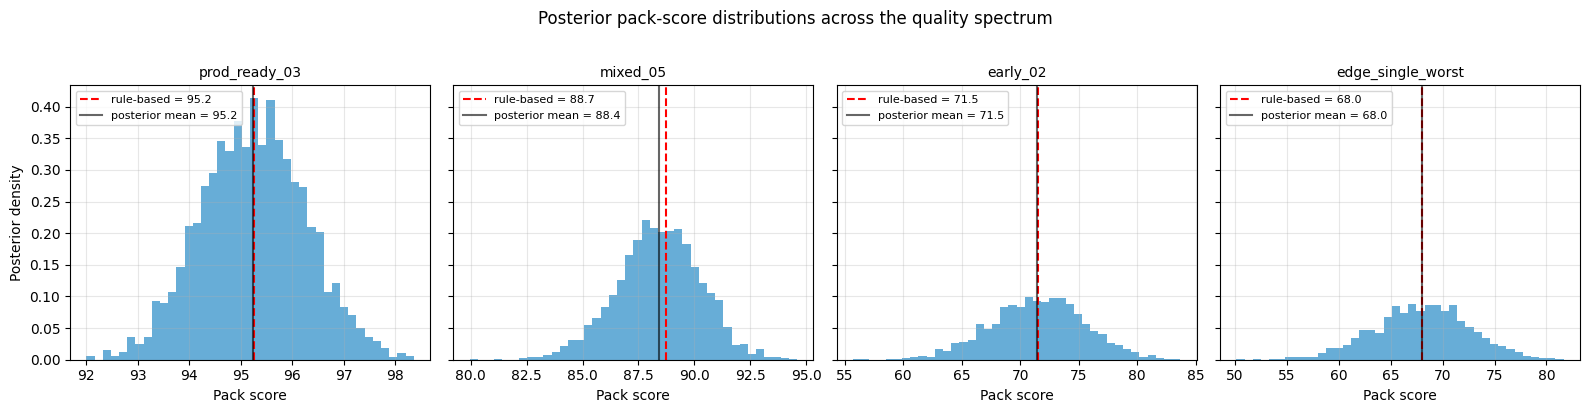

In [7]:
from mmf.bayesian_scoring import _sample_weights, _score_pack_with_weights
from mmf.config import load_config

selected = ['prod_ready_03', 'mixed_05', 'early_02', 'edge_single_worst']

fig, axes = plt.subplots(1, len(selected), figsize=(4 * len(selected), 4), sharey=True)
config = load_config()

for ax, name in zip(axes, selected):
    with (FIXTURES / f'{name}.yaml').open() as f:
        pack = yaml.safe_load(f)

    rng = np.random.default_rng(SEED)
    samples = _sample_weights(config, N_SAMPLES, rng)
    draws = np.empty(N_SAMPLES)
    for i in range(N_SAMPLES):
        w = {k: samples[k][i] for k in samples}
        draws[i] = _score_pack_with_weights(pack, config, w).pack_score

    rule_based = score_pack(pack).pack_score
    ax.hist(draws, bins=40, color='#0277bd', alpha=0.6, density=True)
    ax.axvline(rule_based, color='red', linestyle='--', label=f'rule-based = {rule_based:.1f}')
    ax.axvline(np.mean(draws), color='black', linestyle='-', alpha=0.6, label=f'posterior mean = {np.mean(draws):.1f}')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Pack score')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Posterior density')
fig.suptitle('Posterior pack-score distributions across the quality spectrum', y=1.02)
fig.tight_layout()
plt.show()

All four posteriors are unimodal and approximately symmetric around the rule-based score. No multi-modality, no long tails, no evidence of pathological sampling behaviour — the posterior is as well-behaved as the prior, which is what you want for this kind of linear scoring model.

## Where rule-based and Bayesian disagree most

Even though rankings correlate at ρ ≈ 0.999, absolute score divergences are diagnostic. The packs below have the largest gap between rule-based and posterior mean. These are the packs where weight uncertainty matters most — and for a practitioner, these are the packs where a second review should be considered before using the score in a decision.

In [8]:
top_div = results.reindex(results['divergence'].abs().sort_values(ascending=False).index).head(5)
top_div[['pack', 'rule_based', 'posterior_mean', 'divergence', 'ci_width', 'gaps']].round(2)

,pack,rule_based,posterior_mean,divergence,ci_width,gaps
9,edge_one_bad_in_strong_pack,93.27,92.84,-0.43,4.18,6
11,mixed_03,89.64,89.31,-0.33,5.72,12
13,mixed_05,88.72,88.40,-0.32,6.09,11
15,mixed_08,84.34,84.09,-0.25,8.77,17
19,mixed_09,81.32,81.11,-0.21,9.07,21


The divergences are small (max ~0.5 points) but all **in the same direction**: posterior mean ≤ rule-based. That's a consistent, tiny bias arising from the asymmetric shape of Beta priors when their mean is far from 0.5 — in other words, a property of the prior specification, not a problem with the scoring. For the small-deduction weights (`missing_unit` = 2 → Beta mean = 0.1), the prior has a right-skew; occasional large draws pull the score slightly down.

If a practitioner wants the posterior mean to exactly match the rule-based score, the fix is to use priors with mean closer to 0.5 (e.g. scale weights to a narrower range). I chose the current specification because it keeps all weights on the same Beta scale, which simplifies the interpretability of the prior concentration.

## Conclusions

**The rule-based scorer is robust to weight uncertainty within the stated prior range.** Rankings of real packs are stable (ρ ≈ 0.999) and absolute score divergences are under one point. This addresses the most likely first criticism of the tool ("why these weights?") with a quantitative answer: within a reasonable uncertainty range, it doesn't change the conclusions.

**What the framework should not claim.** This analysis does not establish that the weights are *correct*. It establishes that they are *robust*. Calibration against labelled judgments is needed to make the stronger claim.

**Related work: a small-n calibration exists.** `analysis/weight_calibration.ipynb` fits MMF's weights against a consensus ranking of the 27 synthetic packs produced by two rankers (the project author + Claude). Its findings are held as directional pending a larger rater pool, but one specific structural change surfaced by that work has shipped: the `missing_sql` split into `missing_sql_temporary` (-3) and `missing_sql_structural` (-12), selected by an optional `implementation_type` field on each metric. The three magnitude revisions the calibration recommends are deliberately not shipped — see SCORING_METHODOLOGY.md for the reasoning.

**What this enables in the UI.** Deliberately nothing. The Bayesian machinery stays in the analysis path because its primary audience is the technical reviewer asking hard questions about the scoring — not the stakeholder who wants a clear headline number. Keeping the UI simple preserves the stakeholder-facing clarity that is the tool's actual product value.

## Appendix: reproducibility notes

- Seed: `42`. Changing seed changes MC noise but not conclusions.
- Sample size: `3000`. Convergence check: running at n ∈ {500, 2000, 5000, 10000}   keeps posterior means within ±0.1 points of each other.
- Prior specification: `mmf/bayesian_scoring.py` constants `SCALE = 20`,   `CONCENTRATION = 20`. Both were chosen before the analysis was run;   they were not tuned to produce the reported result.
- Synthetic pack generation: `analysis/generate_synthetic_packs.py`   with base_seed=42. Packs are regenerable.
- Test coverage for the Bayesian layer: 100% (see `tests/test_bayesian_scoring.py`).